# Reinforcement Learning Competition: Race Car

Learn to race a car using the [Gymnasium CarRacing environment](https://gymnasium.farama.org/environments/box2d/car_racing/). You can use any RL method. 

You can use any algorithm from class and libraries like
* [Stable Baseline 3](https://stable-baselines3.readthedocs.io/en/master/)
* [CleanRL](https://github.com/vwxyzjn/cleanrl)


The goal is to reach the highest average returns for 100 race tracks.
Below is code to set up the environment, some simple examples, and code that runs the evaluation.

A good source for DRL is the blog entry: [Solving Gymnasium's Car Racing with Deep Reinforcement Learning](https://www.findingtheta.com/blog/solving-gymnasiums-car-racing-with-reinforcement-learning).

## Setup

In [ ]:
# uncomment if needed
# %pip install "gym-classics2 @ git+https://github.com/mhahsler/gym-classics2.git"
# %pip install pyvirtualdisplay
# %pip install gymnasium[box2d,other]

In [1]:
import numpy as np
np.set_printoptions(precision=2)

In [2]:
import gymnasium as gym
import gym_classics2
gym_classics2.register('gymnasium')

In [3]:
# download if missing
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

download("gymnasium_display_recorder.py", 
         "https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/common/")

# Run The Environment

This runs one episode. Note that the race tracks are randomized, so we use `seed` to make sure that we always get the same track. 

In [4]:
def run_episode(agent_function, env, max_steps=1000, seed = 1, verbose = False):
    """Run one episode in the environment using the provided agent."""

    # Reset the environment to generate the first observation (observation and state are the same in fully observable environments)
    observation, info = env.reset(seed=seed)
    
    # run one episode
    G = 0 # undiscounted episode return
    for i in range(max_steps):
        # call the agent function to select an action
        action = agent_function(observation)

        # step: execute an action in the environment
        observation_prime, reward, terminated, truncated, info = env.step(action)

        if verbose:
            print (f"Step {i+1}: Obs {np.round(observation, 1)} -> Action {action} - > Reward {np.round(reward,1)}, Obs' {np.round(observation_prime,1)}")

        observation = observation_prime
        G += reward

        if terminated:
            break
  
    if verbose:
        print(f"Episode Return: {G}")
    
    return G

## Simple Agent Functions

This agent is a random agent that mostly just accelerates.

In [5]:
def speed_kills_driver(observation): 
    """A random agent that selects actions uniformly at random. It ignores the observation.
    
    Actions
    0: do nothing
    1: steer right
    2: steer left
    3: gas
    4: brake
    """
    return np.random.choice([0, 1, 2, 3, 4], p=[0, 0.1, 0.1, 0.8, 0])

A slightly better simple reflex driver. More on the image processing can be found in the Image Processing section below.

In [6]:
def rgb2gray(rgb):
    return np.dot(rgb[...,:3], [0.2989, 0.5870, 0.1140])


def road_proportions(obs):
    # convert to grayscale
    g = rgb2gray(obs)
    
    # remove dashboard
    g = g[0:84,:]
    
    # detect road pixels
    road_pixels = (g < 150)
    
    # count road pixels on left and right
    road_left = np.sum(road_pixels[:, :40])
    road_right = np.sum(road_pixels[:, 54:])  
    return road_left, road_right

def speed(obs):
    g = rgb2gray(obs)
    speedometer = g[84:,12:13]
    speed = np.sum(speedometer)
    return speed
    
    
def pixel_reflex_driver(observation): 
    """A simple reflex agent that steers based on the road visibility."""
    # Speed up
    if speed(observation) < 600:
        return 3
    
    # Stay in the lane
    road_left, road_right = road_proportions(observation)
    diff = road_left - road_right
    if diff > 80:
        return 2 # steer left
    elif diff < -80:
        return 1 # steer right
    else:
        return 0 # do nothing

## Create a Video

In [7]:
from gymnasium_display_recorder import VideoWrapper, show

env = gym.make("CarRacing-v3", continuous=False, render_mode="rgb_array")
env_record = VideoWrapper(env, 'RC', render_fps=30)

#G = run_episode(speed_kills_driver, env_record, seed=0)
G = run_episode(pixel_reflex_driver, env_record, seed=0)
print(f"Episode Return: {G}")

show(env_record)
env.close()

Videos already exist, I remove them first!


/home/mhahsler/github/Introduction_to_Reinforcement_Learning/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/mhahsler/github/Introduction_to_Reinforcement_Learning/DRL/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episode Return: 605.3291536050037
Showing: ./videos/video_RC-episode-0.mp4


## Evaluation

We use as the evaluation score: Average undiscounted returns over 100 random tracks (random seeds are 0..99).

In [8]:
from tqdm import tqdm

env = gym.make("CarRacing-v3", continuous=False, render_mode=None)

N = 100
Gs = []
for i in tqdm(range(N), desc="Running episodes"):
    #score += run_episode(speed_kills_driver, env, seed=i)
    Gs.append(run_episode(pixel_reflex_driver, env, seed=i))

print(f"Average Return over {N} races: {np.mean(Gs)} +/- {np.std(Gs)}")

env.close()

Running episodes:   0%|          | 0/100 [00:00<?, ?it/s]

Running episodes: 100%|██████████| 100/100 [17:33<00:00, 10.53s/it]

Average Return over 100 races: 511.6219965579753 +/- 289.7883477022364


# What To Do Next

I am sure you can do better. Here are some pointers:

* There is speed and other information in the dash board you could use. You probably could also use a linear approximation with these and the road as features and some feature transformation.
* You could use [convolution layers](https://en.wikipedia.org/wiki/Convolutional_layer) to process the whole input imag and follow the examle in the blog entry above.
* A single image (observation) does not give you information about the car's speed. This actually means that it has a partial observable state. 
  A popular approach is observation stacking by giving the network the current and several prior observations as the input (adding to the tensor depth). 
  This provides temporal context and let's the network estimate the full state representation (including speed) from the data.


# Appendix: Image Processing

Here I try to detect the road.

In [9]:
import gymnasium as gym
env = gym.make("CarRacing-v3", continuous=False, render_mode=None)

# wait for the zoom in to finish and speed up a little
o, info = env.reset()
for i in range(25):
    o, r, t, tr, info = env.step(3)

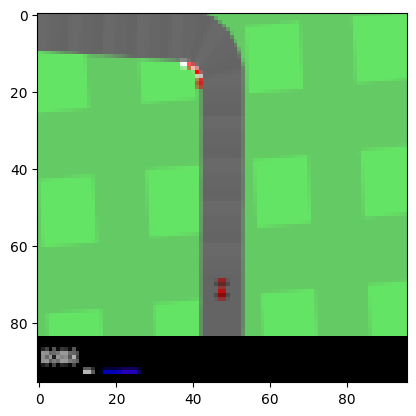

In [13]:
from matplotlib import pyplot as plt

plt.imshow(o)

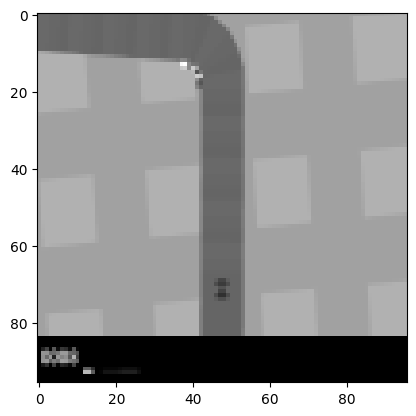

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def rgb2gray(rgb):
    return np.dot(rgb[...,:3], [0.2989, 0.5870, 0.1140])

g = rgb2gray(o)

plt.imshow(g, cmap='gray')


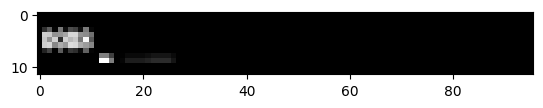

In [15]:
dashboard = g[84:, :] 
plt.imshow(dashboard, cmap='gray')

In [16]:
speedometer = dashboard[:,12:13]

#plt.imshow(speedometer, cmap='gray')
speed = np.sum(speedometer)

print(f"Speed: {speed}")

Speed: 272.9726999999999


Road pixels left: 473, Road pixels right: 0


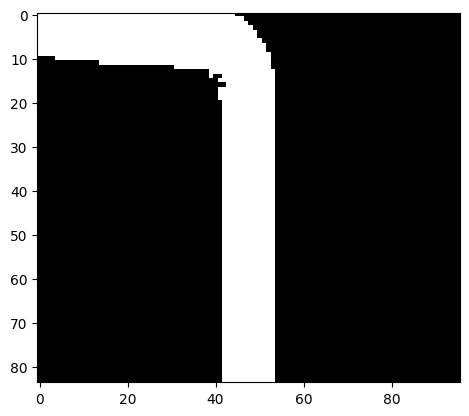

In [17]:
# cut off dashboard
g = g[0:84,:]

# detect road pixels
road_pixels = (g < 150)
plt.imshow(road_pixels, cmap='gray')

# is more road left or right?
road_left = np.sum(road_pixels[:, :40])
road_right = np.sum(road_pixels[:, 54:])  

print (f"Road pixels left: {road_left}, Road pixels right: {road_right}")


&copy; 2026 [Michael Hahsler](https://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)